# Technical Pattern Analysis
Analisis teknikal multi-indiikator untuk screening saham

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Konfigurasi
TICKER = "MU"
PERIOD = "1y"
INTERVAL = "1d"

df = yf.download(TICKER, period=PERIOD, interval=INTERVAL)
df.columns = [col[0] for col in df.columns]
ticker_info = yf.Ticker(TICKER).info

print(f"{TICKER}: {len(df)} days ({df.index[0].date()} - {df.index[-1].date()})")
print(f"Price: ${df['Close'].iloc[-1]:.2f} | MktCap: ${ticker_info.get('marketCap',0):,}")

[*********************100%***********************]  1 of 1 completed


MU: 251 days (2025-05-13 - 2026-05-12)
Price: $766.58 | MktCap: $864,498,352,128


---
## 1. Moving Averages & Trend

In [3]:
ma_periods = [10, 20, 50, 200]
for p in ma_periods:
    df[f'SMA_{p}'] = ta.sma(df['Close'], length=p)

cp = df['Close'].iloc[-1]
print(f"\n{'Period':>6} | {'Value':>10} | {'Signal':>8} | {'Distance':>8}")
print('-' * 45)
for p in ma_periods:
    v = df[f'SMA_{p}'].iloc[-1]
    if pd.notna(v):
        sig = 'BULL' if cp > v else 'BEAR'
        dist = (cp / v - 1) * 100
        print(f"SMA({p:>3}) | ${v:>8.2f} | {sig:>8} | {dist:+>7.1f}%")

# Golden / Death Cross
s50, s200 = df['SMA_50'].iloc[-1], df['SMA_200'].iloc[-1]
if s50 > s200:
    print(f"\n>> Golden Cross: SMA50 (${s50:.2f}) > SMA200 (${s200:.2f})")
else:
    print(f"\n>> Death Cross: SMA50 (${s50:.2f}) < SMA200 (${s200:.2f})")


Period |      Value |   Signal | Distance
---------------------------------------------
SMA( 10) | $  641.64 |     BULL | +++19.5%
SMA( 20) | $  558.88 |     BULL | +++37.2%
SMA( 50) | $  463.64 |     BULL | +++65.3%
SMA(200) | $  297.14 |     BULL | ++158.0%

>> Golden Cross: SMA50 ($463.64) > SMA200 ($297.14)


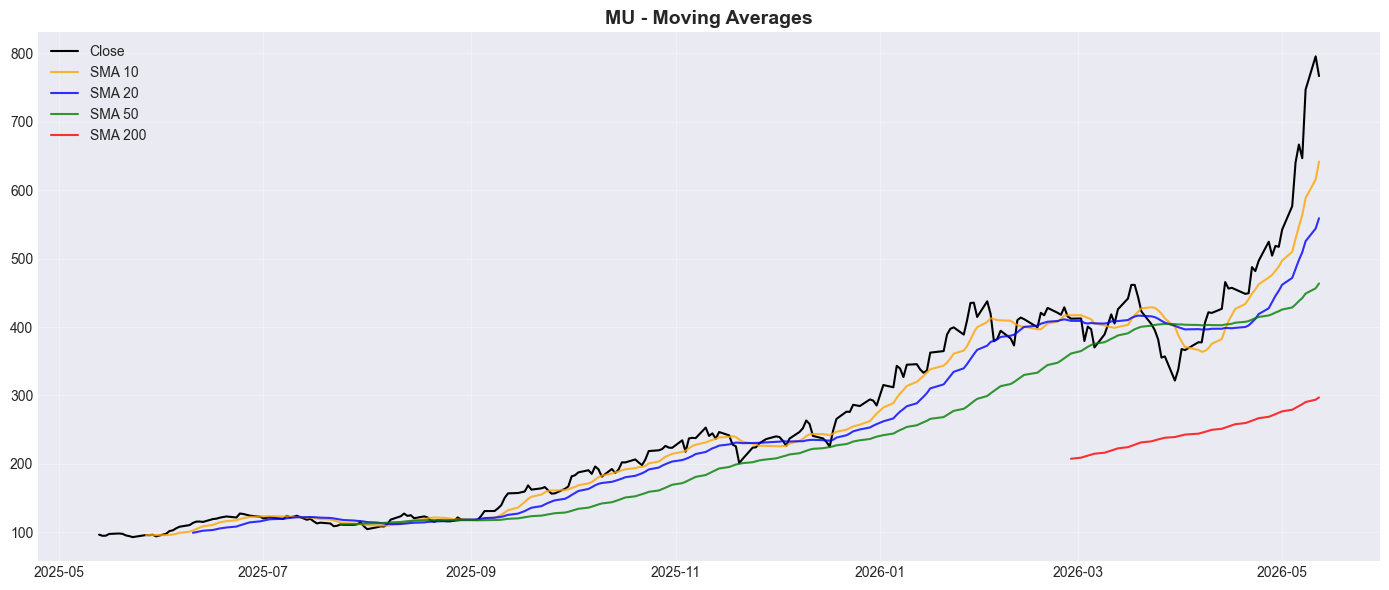

In [4]:
# Visualisasi MA
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], label='Close', color='black', linewidth=1.5)
colors = ['orange', 'blue', 'green', 'red']
for p, c in zip(ma_periods, colors):
    ax.plot(df.index, df[f'SMA_{p}'], label=f'SMA {p}', color=c, alpha=0.8)
ax.set_title(f'{TICKER} - Moving Averages', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. MACD (Moving Average Convergence Divergence)

In [5]:
macd = ta.macd(df['Close'])
df['MACD'] = macd.iloc[:, 0]
df['MACD_Signal'] = macd.iloc[:, 1]
df['MACD_Hist'] = macd.iloc[:, 2]

m, s, h = df['MACD'].iloc[-1], df['MACD_Signal'].iloc[-1], df['MACD_Hist'].iloc[-1]
print(f"MACD: {m:.2f} | Signal: {s:.2f} | Histogram: {h:.2f}")
print(f"Status: {'BULLISH' if m > s else 'BEARISH'} (MACD {'above' if m > s else 'below'} signal)")

# Crossover detection
if m > s and df['MACD'].iloc[-2] <= df['MACD_Signal'].iloc[-2]:
    print(">> BULLISH CROSSOVER baru saja!")
elif m < s and df['MACD'].iloc[-2] >= df['MACD_Signal'].iloc[-2]:
    print(">> BEARISH CROSSOVER baru saja!")

MACD: 83.95 | Signal: 25.79 | Histogram: 58.16
Status: BULLISH (MACD above signal)


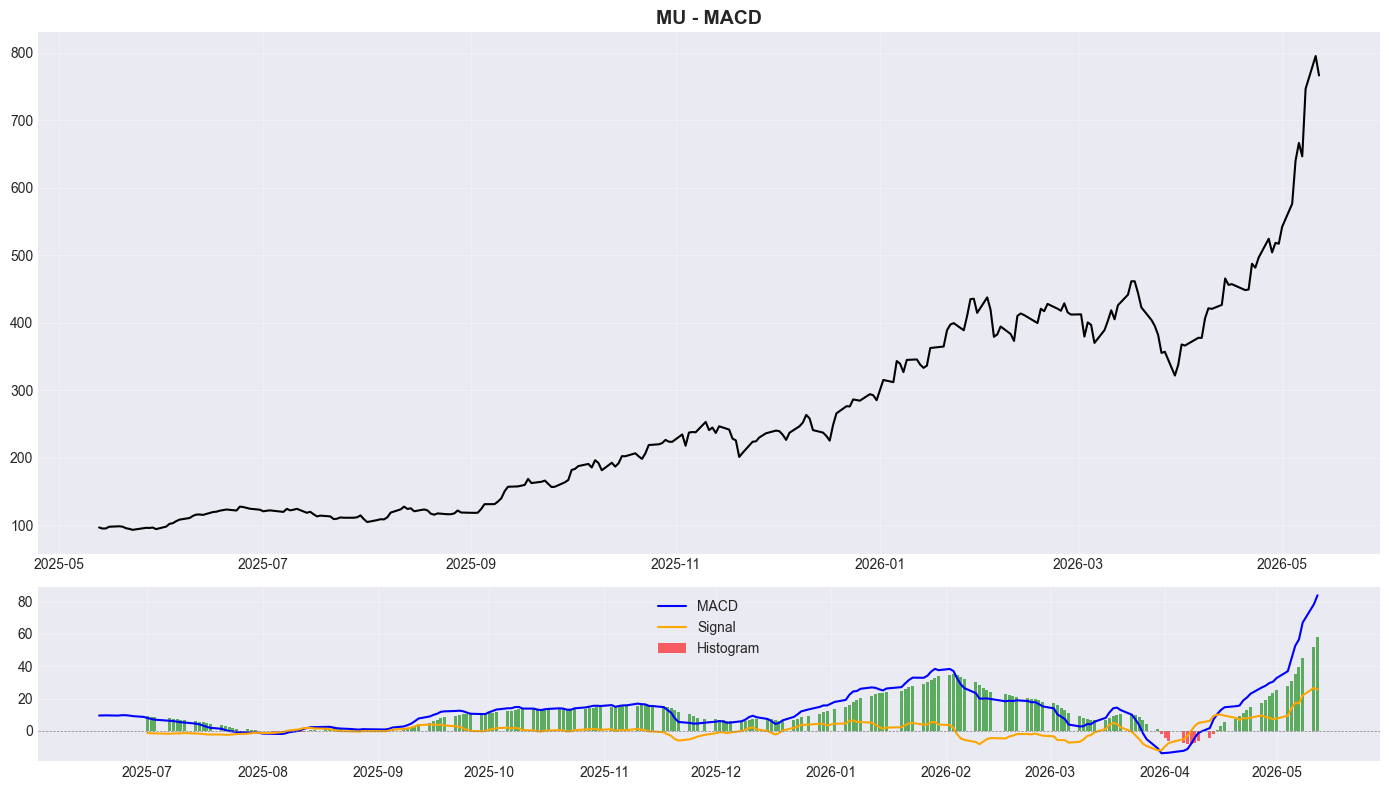

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df.index, df['Close'], color='black', linewidth=1.5)
ax1.set_title(f'{TICKER} - MACD', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['MACD'], label='MACD', color='blue')
ax2.plot(df.index, df['MACD_Signal'], label='Signal', color='orange')
colors = ['green' if v >= 0 else 'red' for v in df['MACD_Hist']]
ax2.bar(df.index, df['MACD_Hist'], color=colors, alpha=0.6, label='Histogram')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. RSI & Momentum

In [7]:
df['RSI'] = ta.rsi(df['Close'], length=14)
rsi_v = df['RSI'].iloc[-1]

print(f"RSI(14): {rsi_v:.2f}")
if rsi_v > 70:
    print(">> OVERBOUGHT - potensi koreksi")
elif rsi_v < 30:
    print(">> OVERSOLD - potensi bounce")
elif 40 <= rsi_v <= 60:
    print(">> Netral")
elif rsi_v > 60:
    print(">> Bullish momentum")

RSI(14): 79.40
>> OVERBOUGHT - potensi koreksi


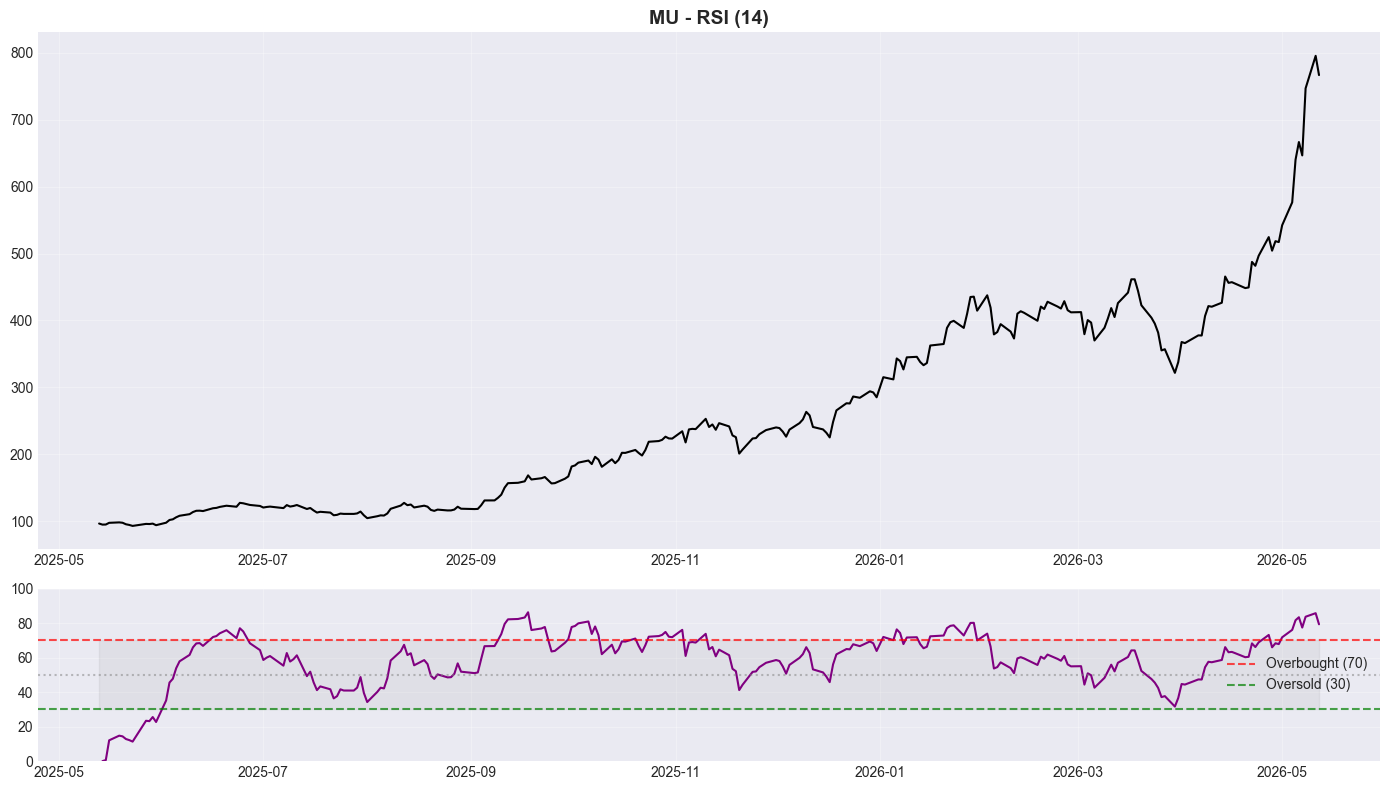

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df.index, df['Close'], color='black', linewidth=1.5)
ax1.set_title(f'{TICKER} - RSI (14)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax2.fill_between(df.index, 30, 70, alpha=0.1, color='gray')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Bollinger Bands

In [9]:
bb = ta.bbands(df['Close'], length=20, std=2)
df['BB_Upper'] = bb.iloc[:, 2]
df['BB_Mid'] = bb.iloc[:, 1]
df['BB_Lower'] = bb.iloc[:, 0]

bb_u, bb_m, bb_l = df['BB_Upper'].iloc[-1], df['BB_Mid'].iloc[-1], df['BB_Lower'].iloc[-1]
bb_pct = (cp - bb_l) / (bb_u - bb_l) * 100

print(f"Upper Band: ${bb_u:.2f}")
print(f"Middle:     ${bb_m:.2f}")
print(f"Lower Band: ${bb_l:.2f}")
print(f"Width:      ${bb_u - bb_l:.2f}")
print(f"%B:         {bb_pct:.1f}%")
print(f"\n>> Price is {'ABOVE' if cp > bb_u else 'NEAR' if bb_pct > 80 else 'INSIDE'} upper band")

# Bandwidth contraction (squeeze)
bw = (bb_u - bb_l) / bb_m * 100
bw_20d_ago = (df['BB_Upper'].iloc[-21] - df['BB_Lower'].iloc[-21]) / df['BB_Mid'].iloc[-21] * 100
print(f"Bandwidth: {bw:.1f}% {'(squeezing)' if bw < bw_20d_ago else '(expanding)'}")

Upper Band: $783.26
Middle:     $558.88
Lower Band: $334.49
Width:      $448.77
%B:         96.3%

>> Price is NEAR upper band
Bandwidth: 80.3% (expanding)


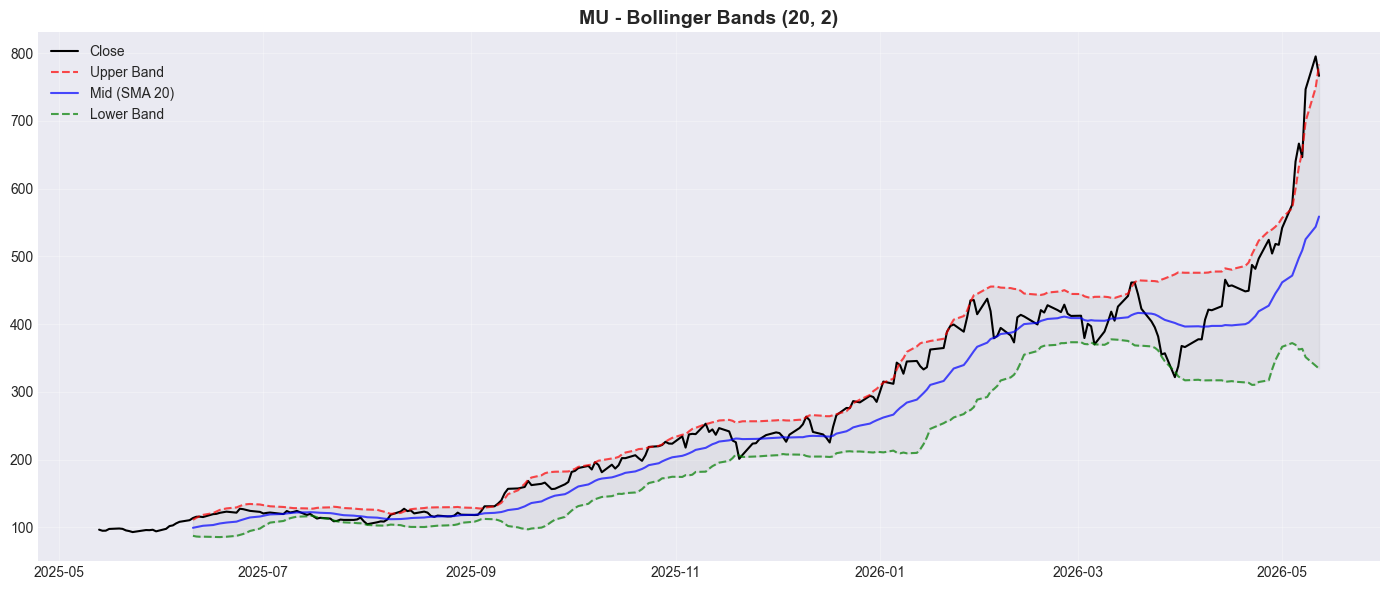

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(df.index, df['BB_Upper'], label='Upper Band', color='red', alpha=0.7, linestyle='--')
ax.plot(df.index, df['BB_Mid'], label='Mid (SMA 20)', color='blue', alpha=0.7)
ax.plot(df.index, df['BB_Lower'], label='Lower Band', color='green', alpha=0.7, linestyle='--')
ax.fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='gray')
ax.set_title(f'{TICKER} - Bollinger Bands (20, 2)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Candlestick Patterns

In [11]:
# Deteksi pattern dengan pandas_ta
pat = ta.cdl_pattern(df['Open'], df['High'], df['Low'], df['Close'], name='all')

print("Candlestick patterns terdeteksi (10 hari terakhir):")
print('-' * 60)
for i in range(1, 11):
    found = []
    for col in pat.columns:
        v = pat[col].iloc[-i]
        if v != 0:
            direction = 'BULL' if v > 0 else 'BEAR'
            found.append(f"{col}({direction})")
    if found:
        print(f"{df.index[-i].date()}: {', '.join(found)}")

[i] Requires TA-Lib to use 2crows. (pip install TA-Lib)
[i] Requires TA-Lib to use 3blackcrows. (pip install TA-Lib)
[i] Requires TA-Lib to use 3inside. (pip install TA-Lib)
[i] Requires TA-Lib to use 3linestrike. (pip install TA-Lib)
[i] Requires TA-Lib to use 3outside. (pip install TA-Lib)
[i] Requires TA-Lib to use 3starsinsouth. (pip install TA-Lib)
[i] Requires TA-Lib to use 3whitesoldiers. (pip install TA-Lib)
[i] Requires TA-Lib to use abandonedbaby. (pip install TA-Lib)
[i] Requires TA-Lib to use advanceblock. (pip install TA-Lib)
[i] Requires TA-Lib to use belthold. (pip install TA-Lib)
[i] Requires TA-Lib to use breakaway. (pip install TA-Lib)
[i] Requires TA-Lib to use closingmarubozu. (pip install TA-Lib)
[i] Requires TA-Lib to use concealbabyswall. (pip install TA-Lib)
[i] Requires TA-Lib to use counterattack. (pip install TA-Lib)
[i] Requires TA-Lib to use darkcloudcover. (pip install TA-Lib)
[i] Requires TA-Lib to use dojistar. (pip install TA-Lib)
[i] Requires TA-Lib to

[i] Requires TA-Lib to use invertedhammer. (pip install TA-Lib)
[i] Requires TA-Lib to use kicking. (pip install TA-Lib)
[i] Requires TA-Lib to use kickingbylength. (pip install TA-Lib)
[i] Requires TA-Lib to use ladderbottom. (pip install TA-Lib)
[i] Requires TA-Lib to use longleggeddoji. (pip install TA-Lib)
[i] Requires TA-Lib to use longline. (pip install TA-Lib)
[i] Requires TA-Lib to use marubozu. (pip install TA-Lib)
[i] Requires TA-Lib to use matchinglow. (pip install TA-Lib)
[i] Requires TA-Lib to use mathold. (pip install TA-Lib)
[i] Requires TA-Lib to use morningdojistar. (pip install TA-Lib)
[i] Requires TA-Lib to use morningstar. (pip install TA-Lib)
[i] Requires TA-Lib to use onneck. (pip install TA-Lib)
[i] Requires TA-Lib to use piercing. (pip install TA-Lib)
[i] Requires TA-Lib to use rickshawman. (pip install TA-Lib)
[i] Requires TA-Lib to use risefall3methods. (pip install TA-Lib)
[i] Requires TA-Lib to use separatinglines. (pip install TA-Lib)
[i] Requires TA-Lib to

---
## 6. Support & Resistance

In [12]:
close = df['Close'].values
peaks, troughs = [], []

for i in range(5, len(close)-5):
    if all(close[i] >= close[i-j] for j in range(1,6)) and all(close[i] >= close[i+j] for j in range(1,6)):
        peaks.append((df.index[i], close[i]))
    if all(close[i] <= close[i-j] for j in range(1,6)) and all(close[i] <= close[i+j] for j in range(1,6)):
        troughs.append((df.index[i], close[i]))

def cluster_levels(pts, threshold=0.03):
    if not pts: return []
    vals = sorted([p[1] for p in pts])
    clusters, cur = [], [vals[0]]
    for v in vals[1:]:
        if abs(v - cur[-1]) / max(abs(cur[-1]), 0.01) <= threshold:
            cur.append(v)
        else:
            clusters.append(round(np.mean(cur), 2))
            cur = [v]
    clusters.append(round(np.mean(cur), 2))
    return clusters

resistance = cluster_levels(peaks)
support = cluster_levels(troughs)

# Filter level yang relevan (dekat harga sekarang)
near_res = sorted([r for r in resistance if cp * 0.8 <= r <= cp * 1.3])
near_sup = sorted([s for s in support if cp * 0.5 <= s <= cp * 1.1])

print("\nResistance Levels:")
for r in near_res:
    print(f"  ${r:>8.2f}  ({(r/cp-1)*100:+>7.1f}%)")

print("\nSupport Levels:")
for s in near_sup:
    print(f"  ${s:>8.2f}  ({(s/cp-1)*100:+>7.1f}%)")


Resistance Levels:

Support Levels:


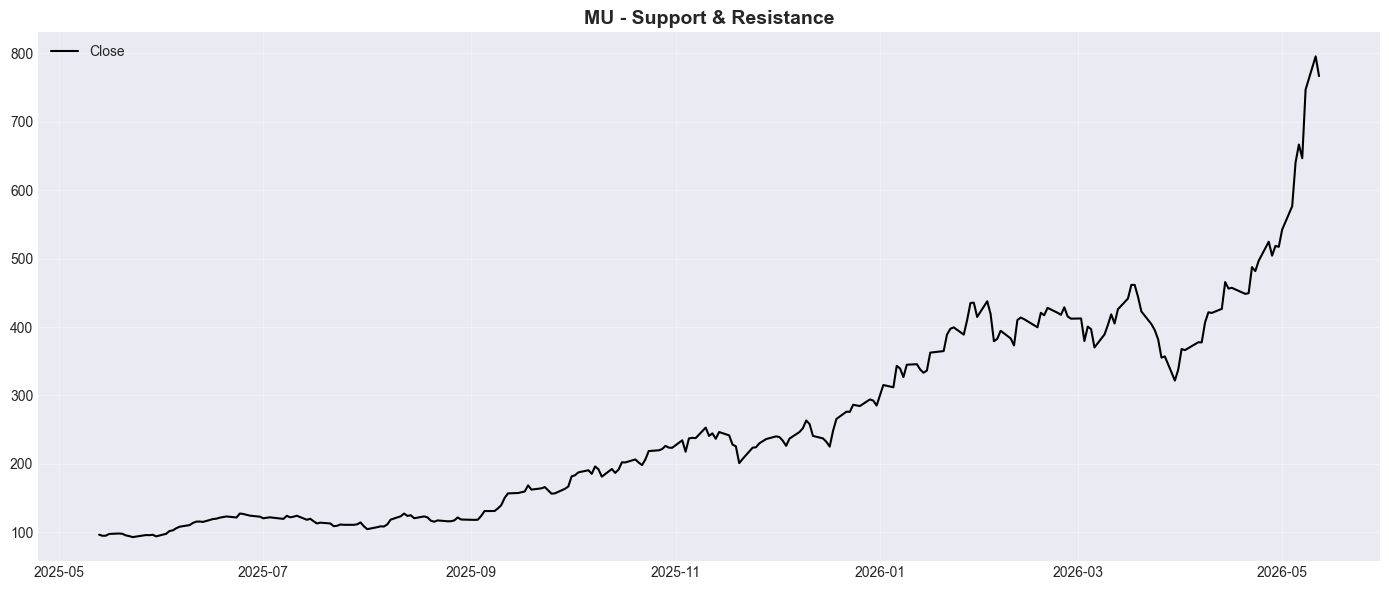

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], label='Close', color='black', linewidth=1.5)

# Plot S&R levels
for r in near_res:
    ax.axhline(y=r, color='red', linestyle='--', alpha=0.5)
    ax.text(df.index[-1], r, f'  ${r:.0f}', color='red', va='center', fontsize=10)
for s in near_sup:
    ax.axhline(y=s, color='green', linestyle='--', alpha=0.5)
    ax.text(df.index[-1], s, f'  ${s:.0f}', color='green', va='center', fontsize=10)

ax.set_title(f'{TICKER} - Support & Resistance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. ADX & Trend Strength

In [14]:
adx = ta.adx(df['High'], df['Low'], df['Close'], length=14)
df['ADX'] = adx.iloc[:, 0]
df['DMP'] = adx.iloc[:, 1]  # +DI
df['DMN'] = adx.iloc[:, 2]  # -DI

adx_v, dmp, dmn = df['ADX'].iloc[-1], df['DMP'].iloc[-1], df['DMN'].iloc[-1]

print(f"ADX(14): {adx_v:.2f}")
print(f"+DI: {dmp:.2f} | -DI: {dmn:.2f}")
print(f"Direction: {'BULLISH' if dmp > dmn else 'BEARISH'}")
if adx_v > 25:
    print(f"Trend Strength: STRONG")
elif adx_v > 20:
    print(f"Trend Strength: MODERATE")
else:
    print(f"Trend Strength: WEAK / RANGING")

ADX(14): 41.57
+DI: 39.84 | -DI: 46.34
Direction: BEARISH
Trend Strength: STRONG


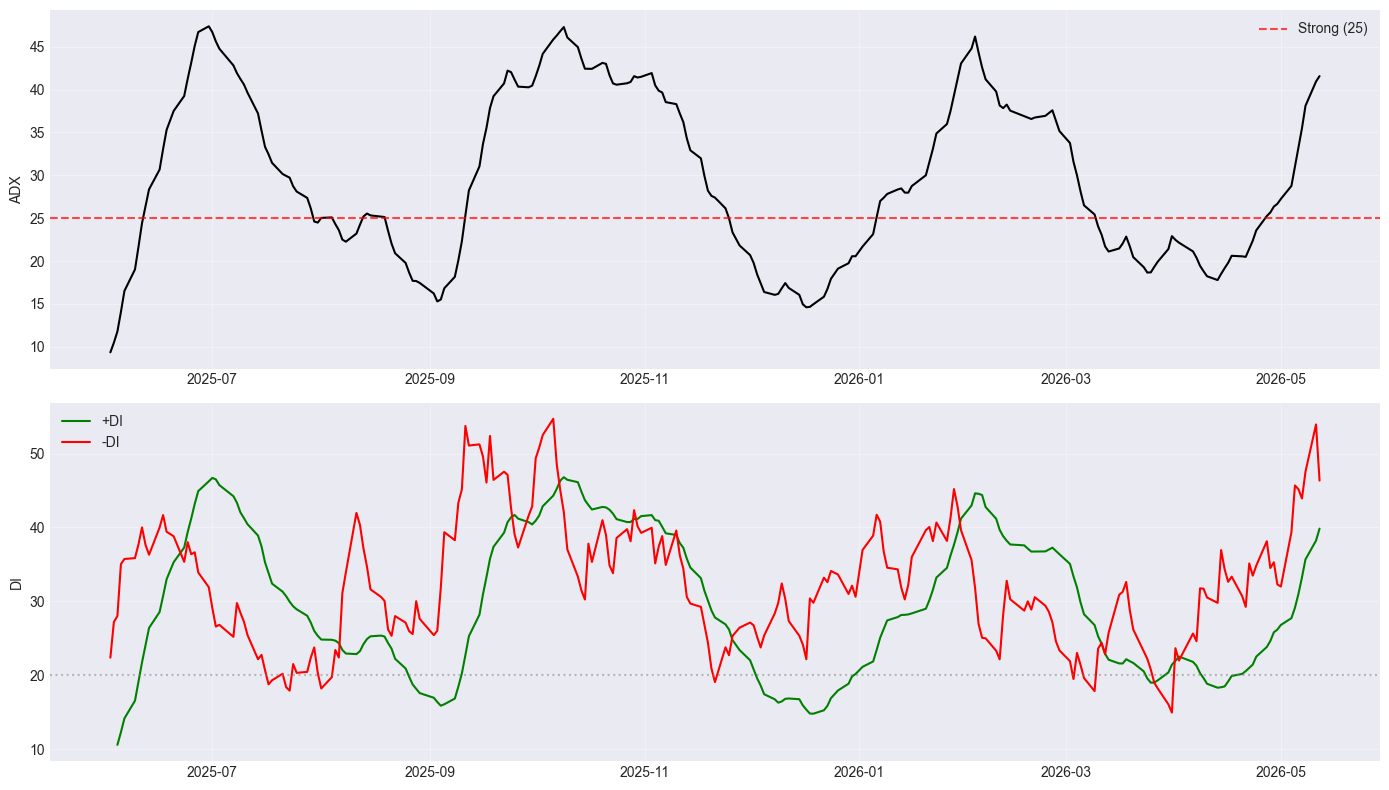

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 1]})

ax1.plot(df.index, df['ADX'], color='black', linewidth=1.5)
ax1.axhline(25, color='red', linestyle='--', alpha=0.7, label='Strong (25)')
"ax1.set_title(f'{TICKER} - ADX (14)', fontsize=14, fontweight='bold')\n",
ax1.set_ylabel('ADX')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['DMP'], label='+DI', color='green')
ax2.plot(df.index, df['DMN'], label='-DI', color='red')
ax2.axhline(20, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylabel('DI')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Volume Analysis

In [16]:
df['Volume_SMA'] = ta.sma(df['Volume'], length=20)
df['OBV'] = ta.obv(df['Close'], df['Volume'])

last_vol = df['Volume'].iloc[-1]
avg_vol = df['Volume_SMA'].iloc[-1]
vr = last_vol / avg_vol if avg_vol > 0 else 0

print(f"Volume Terakhir: {last_vol:>12,.0f}")
print(f"Rata-rata (20d): {avg_vol:>12,.0f}")
print(f"Volume Ratio:    {vr:.2f}x")

if vr > 2:
    print(">> VOLUME SPIKES - konfirmasi kuat")
elif vr > 1.5:
    print(">> Volume di atas rata-rata")
elif vr < 0.5:
    print(">> Volume rendah - kurang konviktif")
else:
    print(">> Volume normal")

# OBV
obv_now = df['OBV'].iloc[-1]
obv_20d = df['OBV'].iloc[-21]
obv_pct = (obv_now / obv_20d - 1) * 100
price_20d_pct = (cp / df['Close'].iloc[-21] - 1) * 100
print(f"\nOBV 20d Change: {obv_pct:+.1f}%")
print(f"Price 20d Change: {price_20d_pct:+.1f}%")
if (obv_pct > 0) == (price_20d_pct > 0):
    print(">> OBV CONFIRMING price movement")
else:
    print(">> OBV DIVERGENCE - price/volume mismatch")

Volume Terakhir:   73,115,800
Rata-rata (20d):   45,431,175
Volume Ratio:    1.61x
>> Volume di atas rata-rata

OBV 20d Change: +23.2%
Price 20d Change: +64.6%
>> OBV CONFIRMING price movement


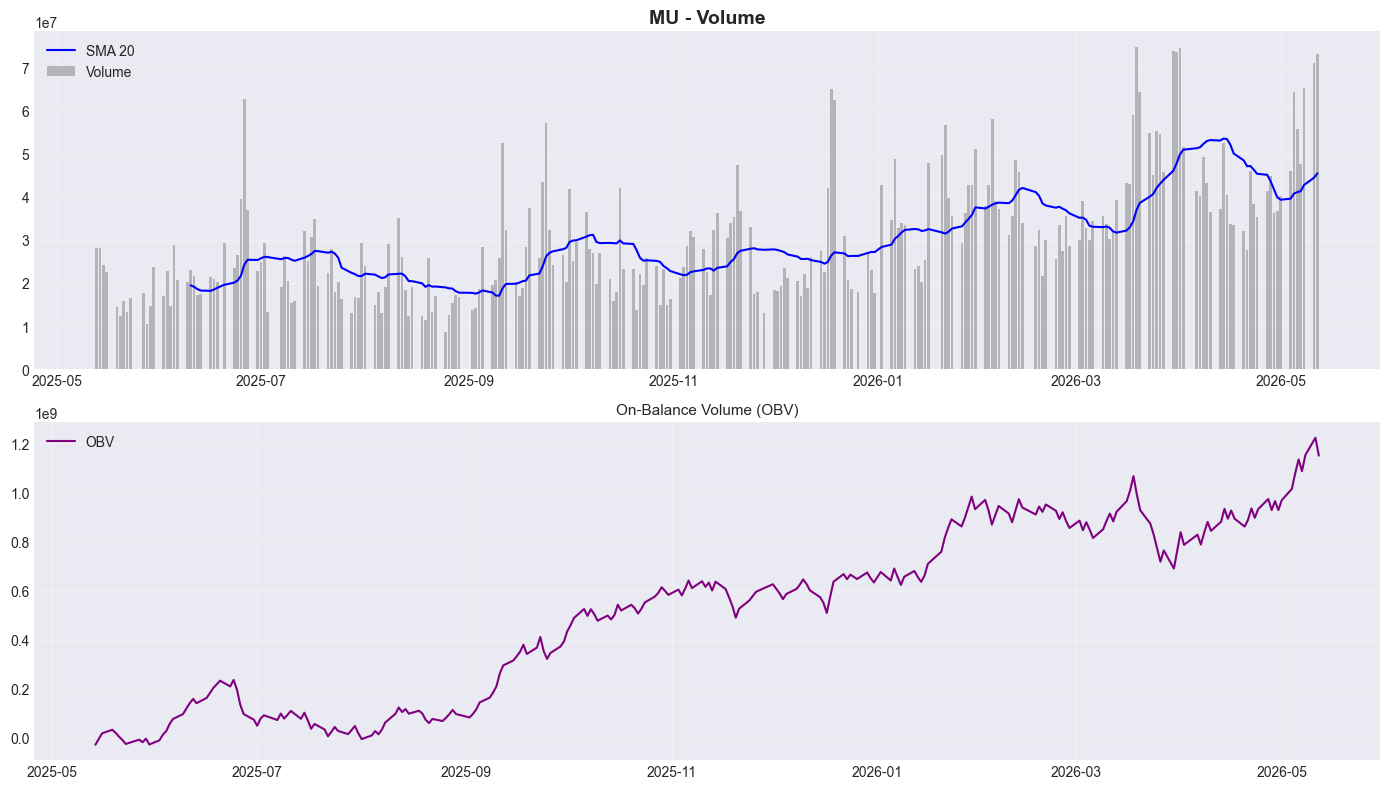

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 1]})

ax1.bar(df.index, df['Volume'], color='gray', alpha=0.5, label='Volume')
ax1.plot(df.index, df['Volume_SMA'], color='blue', linewidth=1.5, label='SMA 20')
ax1.set_title(f'{TICKER} - Volume', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['OBV'], color='purple', linewidth=1.5, label='OBV')
ax2.set_title('On-Balance Volume (OBV)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Ichimoku Cloud

In [18]:
ichi = ta.ichimoku(df['High'], df['Low'], df['Close'])
senkou_a = ichi[0].iloc[:, 0]
senkou_b = ichi[0].iloc[:, 1]
kijun = ichi[0].iloc[:, 2] if ichi[0].shape[1] > 2 else None

cloud_top = np.maximum(senkou_a, senkou_b)
cloud_bot = np.minimum(senkou_a, senkou_b)

print(f"Senkou A (Leading A): ${senkou_a.iloc[-1]:.2f}")
print(f"Senkou B (Leading B): ${senkou_b.iloc[-1]:.2f}")
print(f"Cloud Top: ${cloud_top.iloc[-1]:.2f}")
print(f"Cloud Bot: ${cloud_bot.iloc[-1]:.2f}")

if cp > cloud_top.iloc[-1]:
    print("\n>> Price ABOVE Cloud: BULLISH")
elif cp < cloud_bot.iloc[-1]:
    print("\n>> Price BELOW Cloud: BEARISH")
else:
    print("\n>> Price INSIDE Cloud: NEUTRAL / TRANSITION")

Senkou A (Leading A): $370.72
Senkou B (Leading B): $391.32
Cloud Top: $391.32
Cloud Bot: $370.72

>> Price ABOVE Cloud: BULLISH


C:\Users\Qyuarius\AppData\Local\Temp\ipykernel_20900\2368038481.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  ichi = ta.ichimoku(df['High'], df['Low'], df['Close'])


---
## 10. Summary Dashboard

In [19]:
print("=" * 60)
print(f"  TECHNICAL SUMMARY: {TICKER}")
print(f"  {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)

# Hitung 1Y trend
X = np.arange(len(df)).reshape(-1, 1)
lr = LinearRegression().fit(X, df['Close'].values)

checks = [
    ("Price > SMA(20)", cp > df['SMA_20'].iloc[-1]),
    ("Price > SMA(50)", cp > df['SMA_50'].iloc[-1]),
    ("Price > SMA(200)", cp > df['SMA_200'].iloc[-1]),
    ("Golden Cross (50>200)", df['SMA_50'].iloc[-1] > df['SMA_200'].iloc[-1]),
    ("MACD > Signal", m > s),
    ("MACD Histogram Positif", h > 0),
    ("RSI < 70 (not OB)", rsi_v < 70),
    ("RSI > 30 (not OS)", rsi_v > 30),
    ("ADX > 25 (strong trend)", adx_v > 25),
    ("+DI > -DI", dmp > dmn),
    ("BB %B in range", 5 < bb_pct < 95),
    ("Volume confirming", (obv_now > obv_20d) == (cp > df['Close'].iloc[-21])),
    ("Above Ichimoku Cloud", cp > cloud_top.iloc[-1]),
    ("1Y Uptrend", lr.coef_[0] > 0),
]

bull = sum(1 for _, r in checks if r)
bear = len(checks) - bull

for label, result in checks:
    icon = "OK" if result else "XX"
    print(f"  [{icon}] {label}")

print(f"\n  Bullish: {bull}/{len(checks)} | Bearish: {bear}/{len(checks)}")

ratio = bull / len(checks)
if ratio >= 0.7:
    verdict = "STRONG BULLISH"
elif ratio >= 0.5:
    verdict = "BULLISH BIAS"
elif ratio >= 0.3:
    verdict = "NEUTRAL / CAUTIOUS"
else:
    verdict = "BEARISH BIAS"
print(f"\n  >>> VERDICT: {verdict} <<<")
print("=" * 60)

  TECHNICAL SUMMARY: MU
  2026-05-13 12:47
  [OK] Price > SMA(20)
  [OK] Price > SMA(50)
  [OK] Price > SMA(200)
  [OK] Golden Cross (50>200)
  [OK] MACD > Signal
  [OK] MACD Histogram Positif
  [XX] RSI < 70 (not OB)
  [OK] RSI > 30 (not OS)
  [OK] ADX > 25 (strong trend)
  [XX] +DI > -DI
  [XX] BB %B in range
  [OK] Volume confirming
  [OK] Above Ichimoku Cloud
  [OK] 1Y Uptrend

  Bullish: 11/14 | Bearish: 3/14

  >>> VERDICT: STRONG BULLISH <<<


---
## Catatan
- Data dari Yahoo Finance
- Tidak ada saran beli/jual, hanya untuk edukasi
- Install TA-Lib untuk deteksi candlestick pattern yang lebih lengkap: `pip install TA-Lib`